# EXPL_05 — Horizon Comparison

This notebook compares whether global SHAP importance remains stable across the
representative horizons. A large shift would justify expanding SHAP beyond the
initial five horizons.


In [1]:
# Import libraries
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "explainability.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/explainability.yaml')

In [3]:
# Import modules for generating explainability
from src.ontario_peak_risk.explainability.common import (
    load_explainability_config,
    ensure_phase_directories,
    load_final_metadata,
)

In [4]:
# Load parameters
config, project_root = load_explainability_config(CONFIG_PATH)
phase_paths = ensure_phase_directories(config, project_root)
metadata = load_final_metadata(config, project_root)

print("Project root:", project_root)
print("RF:", metadata["rf"]["algorithm"], "| horizons:", metadata["rf"]["horizons"])
print("XGB:", metadata["xgb"]["algorithm"], "| horizons:", metadata["xgb"]["horizons"])
print("Explainability output:", phase_paths["outputs_dir"])


Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
RF: RandomForestRegressor | horizons: 24
XGB: XGBoostClassifier | horizons: 24
Explainability output: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\explainability


In [6]:
from src.ontario_peak_risk.explainability.plotting import shap_horizon_heatmap

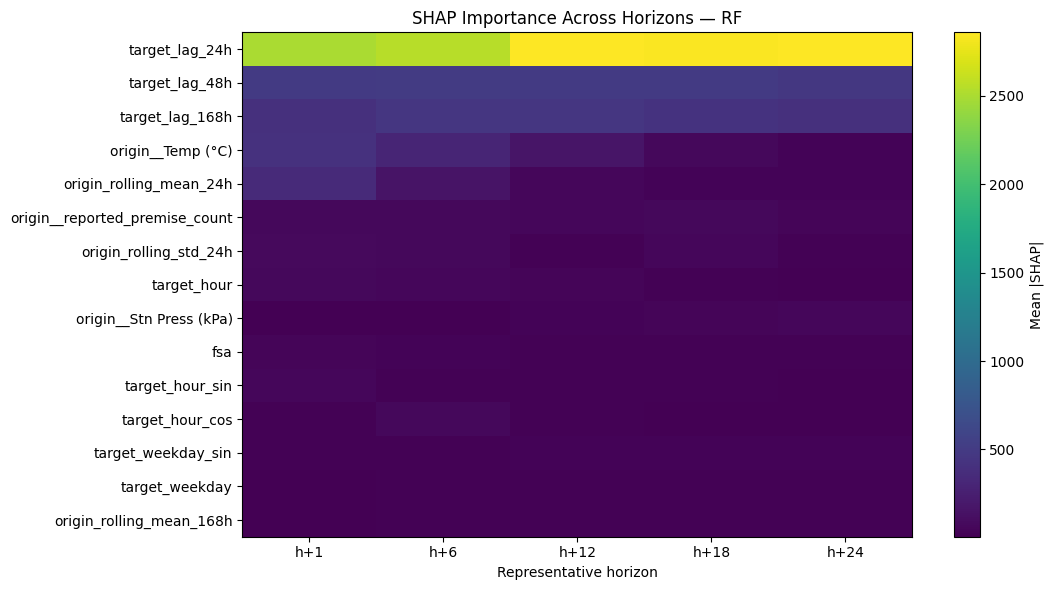

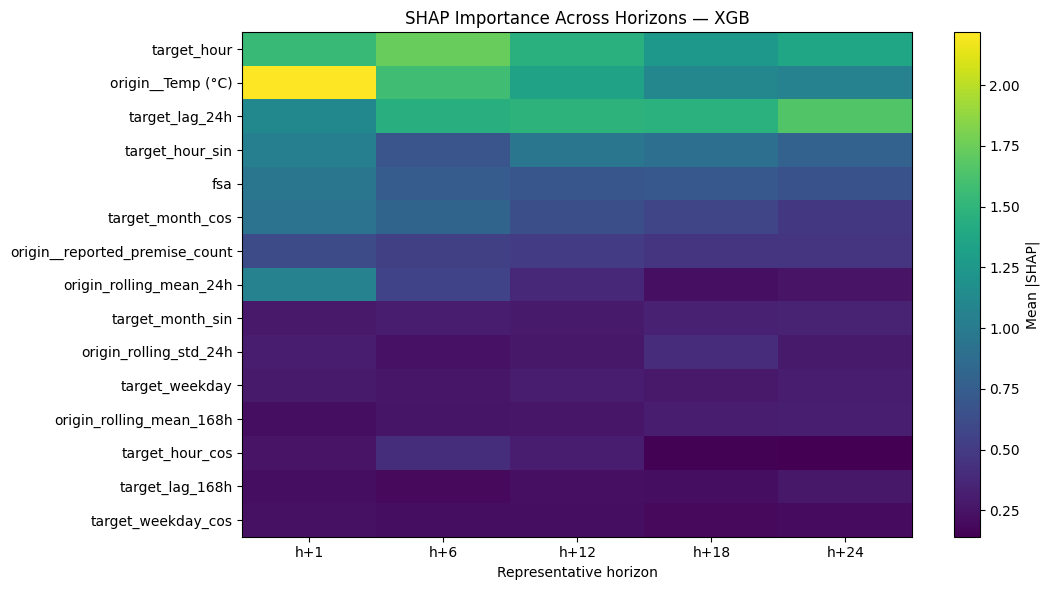

In [7]:
# Display SHAP headmap
shap_global = pd.read_csv(
    phase_paths["outputs_dir"] / "EXPL_02_shap_global_by_horizon.csv"
)

for task in ["rf", "xgb"]:
    shap_horizon_heatmap(shap_global, task, top_n=15)
    plt.show()


In [8]:
# Rank-correlation diagnostic across representative horizons.
rank_rows = []
for task in ["rf", "xgb"]:
    task_frame = shap_global.loc[shap_global["task"].eq(task)]
    pivot = task_frame.pivot(
        index="feature",
        columns="horizon",
        values="mean_abs_shap",
    ).fillna(0)

    corr = pivot.rank(ascending=False).corr(method="spearman")
    for h1 in corr.index:
        for h2 in corr.columns:
            if h1 < h2:
                rank_rows.append({
                    "task": task,
                    "horizon_1": h1,
                    "horizon_2": h2,
                    "spearman_rank_correlation": corr.loc[h1, h2],
                })

rank_stability = pd.DataFrame(rank_rows)
display(rank_stability)
rank_stability.to_csv(
    phase_paths["outputs_dir"] / "EXPL_05_horizon_rank_stability.csv",
    index=False,
)

print("EXPL_05 RESULT: COMPLETE")


,task,horizon_1,horizon_2,spearman_rank_correlation
0,rf,1,6,0.928854
1,rf,1,12,0.815923
2,rf,1,18,0.770751
3,rf,1,24,0.620553
4,rf,6,12,0.905138
5,rf,6,18,0.802372
6,rf,6,24,0.640881
7,rf,12,18,0.906268
8,rf,12,24,0.800113
9,rf,18,24,0.933371


EXPL_05 RESULT: COMPLETE


In [9]:
# ---------------------------------------------------------------
# Save EXPL_05 documentation
# ---------------------------------------------------------------

report_path = (
    phase_paths["docs_dir"]
    / "EXPL_05_Horizon_Comparison.md"
)

rf_corr = rank_stability.loc[
    rank_stability["task"].eq("rf"),
    "spearman_rank_correlation"
]

xgb_corr = rank_stability.loc[
    rank_stability["task"].eq("xgb"),
    "spearman_rank_correlation"
]

report = f"""# EXPL_05 — Horizon Comparison

## Purpose

This analysis evaluates the stability of SHAP feature-importance rankings
across the representative horizons h+1, h+6, h+12, h+18, and h+24.

## Results

### Random Forest

- Mean Spearman correlation: {rf_corr.mean():.3f}
- Minimum correlation: {rf_corr.min():.3f}
- Maximum correlation: {rf_corr.max():.3f}

The Random Forest explanations remain broadly consistent, but similarity
decreases as the distance between forecast horizons increases. The largest
difference occurs between h+1 and h+24.

### XGBoost

- Mean Spearman correlation: {xgb_corr.mean():.3f}
- Minimum correlation: {xgb_corr.min():.3f}
- Maximum correlation: {xgb_corr.max():.3f}

XGBoost shows high explanatory stability across the representative horizons.

## Interpretation

The results support the use of representative horizons for the SHAP analysis.
They also indicate that forecast-horizon effects are more pronounced for the
Random Forest demand model than for the XGBoost Peak-Risk classifier.

These results describe model-behavior stability and should not be interpreted
causally.
"""

report_path.write_text(report, encoding="utf-8")

print("Saved:", report_path)
print("EXPL_05 documentation complete.")

Saved: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\docs\explainability\EXPL_05_Horizon_Comparison.md
EXPL_05 documentation complete.
